In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

In [3]:
!pip install pyswarms

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 4.0 MB/s eta 0:00:00


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (accuracy_score,classification_report,confusion_matrix,ConfusionMatrixDisplay)
from sklearn.decomposition import PCA
import pyswarms as ps
from pyswarms.discrete import BinaryPSO

In [5]:
# ── 1. Load & subsample ──────────────────────────────────────
SAMPLE_SIZE = 10_000
RANDOM_SEED = 42
K_NEIGHBORS = 5   # fixed k for PSO evaluation
print("Loading dataset …")
data = pd.read_csv("/content/drive/MyDrive/Dataset/A_Z Handwritten Data.csv").astype('float32')

Loading dataset …


In [6]:
# Subsample stratified so all 26 classes are represented
data = data.groupby('0', group_keys=False).apply( lambda g: g.sample(min(len(g), SAMPLE_SIZE // 26), random_state=RANDOM_SEED)).reset_index(drop=True)
X = data.drop('0', axis=1).values
y = data['0'].values.astype(int)
print(f"Working dataset shape: {X.shape}")

Working dataset shape: (9984, 784)


/tmp/ipykernel_864/35255587.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data = data.groupby('0', group_keys=False).apply( lambda g: g.sample(min(len(g), SAMPLE_SIZE // 26), random_state=RANDOM_SEED)).reset_index(drop=True)


In [7]:
# ── 2. Normalise ─────────────────────────────────────────────
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [9]:
# ── 3. Train / test split ────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)
n_features = X_train.shape[1]

In [10]:
# ── 4. Baseline KNN (all features) ───────────────────────────
print("\n── Baseline KNN ──")
t0 = time.time()
knn_base = KNeighborsClassifier(n_neighbors=K_NEIGHBORS, n_jobs=-1)
knn_base.fit(X_train, y_train)
y_pred_base = knn_base.predict(X_test)
t_base = time.time() - t0

acc_base = accuracy_score(y_test, y_pred_base)
print(f"Accuracy  : {acc_base:.4f}")
print(f"Time      : {t_base:.1f}s")
print(classification_report(y_test, y_pred_base,
      target_names=[chr(65+i) for i in range(26)]))


── Baseline KNN ──
Accuracy  : 0.8538
Time      : 1.2s
              precision    recall  f1-score   support

           A       0.77      0.87      0.81        76
           B       0.90      0.78      0.83        77
           C       0.83      1.00      0.91        77
           D       0.82      0.75      0.78        77
           E       0.89      0.73      0.80        77
           F       0.83      0.94      0.88        77
           G       0.88      0.83      0.85        77
           H       0.73      0.86      0.79        77
           I       0.96      0.96      0.96        76
           J       0.90      0.92      0.91        77
           K       0.82      0.88      0.85        77
           L       0.80      0.96      0.87        76
           M       0.97      0.91      0.94        77
           N       0.78      0.79      0.79        77
           O       0.74      0.87      0.80        77
           P       0.63      0.83      0.72        77
           Q       0.87  

In [11]:
# ── 5. PSO Feature Selection ──────────────────────────────────
# minimise both error AND number of features.
LAMBDA = 0.01   # penalty weight for using too many features
def fitness_function(position):
    n_particles = position.shape[0]
    costs = np.zeros(n_particles)
    for i in range(n_particles):
        selected = position[i].astype(bool)
        # If no feature selected, penalise heavily
        if selected.sum() == 0:
            costs[i] = 1.0 + LAMBDA
            continue
        X_tr = X_train[:, selected]
        X_te = X_test[:, selected]
        knn = KNeighborsClassifier(n_neighbors=K_NEIGHBORS, n_jobs=-1)
        knn.fit(X_tr, y_train)
        acc = accuracy_score(y_test, knn.predict(X_te))
        # Fitness = classification error + feature ratio penalty
        costs[i] = (1.0 - acc) + LAMBDA * (selected.sum() / n_features)
    return costs

In [12]:
# PSO hyper-parameters
# n_particles  : number of candidate feature subsets explored in parallel
# iters        : number of PSO iterations
pso_options = {'c1': 0.5, 'c2': 0.5, 'w': 0.9, 'k': 10, 'p': 2}
print("\n── Running Binary PSO (this may take a few minutes) ──")
optimizer = BinaryPSO(
    n_particles=20,
    dimensions=n_features,
    options=pso_options
)
t_pso_start = time.time()
best_cost, best_pos = optimizer.optimize(fitness_function, iters=20, verbose=True)
t_pso = time.time() - t_pso_start
print(f"\nPSO finished in {t_pso:.1f}s")

2026-04-23 22:45:01,914 - pyswarms.discrete.binary - INFO - Optimize for 20 iters with {'c1': 0.5, 'c2': 0.5, 'w': 0.9, 'k': 10, 'p': 2}



── Running Binary PSO (this may take a few minutes) ──


pyswarms.discrete.binary: 100%|██████████|20/20, best_cost=0.15
2026-04-23 22:48:43,882 - pyswarms.discrete.binary - INFO - Optimization finished | best cost: 0.1500487082664814, best pos: [1 0 1 1 1 1 1 0 0 1 1 0 1 1 1 1 0 1 0 1 0 1 1 0 1 0 1 1 0 1 1 1 1 0 1 0 0
 1 0 0 1 0 0 0 0 0 1 0 0 1 1 1 1 0 1 0 0 1 1 0 1 0 0 0 1 0 1 1 1 1 0 1 1 1
 0 1 1 0 1 1 0 1 1 0 1 1 0 0 1 1 0 1 0 0 1 1 1 1 1 1 1 1 1 1 0 0 0 1 1 1 1
 1 0 0 0 0 1 1 0 1 1 1 0 1 1 1 1 1 0 1 0 0 0 1 0 0 1 0 0 1 0 0 1 0 0 0 1 0
 1 1 1 1 1 0 1 1 1 1 0 1 0 1 0 1 1 1 0 0 1 0 0 1 0 0 0 1 0 0 0 1 0 1 0 0 0
 1 0 1 0 1 0 1 1 1 1 0 1 0 1 1 1 0 1 0 0 0 0 0 0 1 0 1 0 0 0 0 1 1 1 1 1 0
 1 0 0 1 1 0 0 1 1 0 0 1 1 0 1 1 1 0 1 1 0 0 1 0 1 1 0 1 0 1 1 1 0 0 1 0 1
 1 1 0 0 0 0 0 1 1 1 0 1 0 0 0 1 1 0 1 1 0 1 0 1 0 1 1 1 1 1 0 0 0 0 0 1 0
 0 0 1 0 1 1 1 0 1 1 1 0 0 0 1 1 1 1 0 1 1 0 1 1 1 1 0 0 0 0 1 1 1 0 1 0 0
 1 1 1 1 0 0 0 1 1 0 1 1 1 0 1 1 0 0 1 1 1 1 1 1 0 1 0 1 1 1 0 1 0 1 1 0 1
 1 1 0 0 0 1 0 1 1 1 1 0 0 0 1 1 1 1 1 1 0 1 1 0 1 0 0 0 1 1 


PSO finished in 222.0s


In [13]:
# ── 6. Evaluate PSO-selected features ────────────────────────
selected_mask = best_pos.astype(bool)
n_selected    = selected_mask.sum()
print(f"\nFeatures selected by PSO:{n_selected}/{n_features}"f"({n_selected/n_features*100:.1f}%)")
X_train_pso = X_train[:, selected_mask]
X_test_pso  = X_test[:, selected_mask]
print("\n── KNN on PSO-selected features ──")
t0 = time.time()
knn_pso = KNeighborsClassifier(n_neighbors=K_NEIGHBORS, n_jobs=-1)
knn_pso.fit(X_train_pso, y_train)
y_pred_pso = knn_pso.predict(X_test_pso)
t_pso_knn = time.time() - t0
acc_pso = accuracy_score(y_test, y_pred_pso)
print(f"Accuracy  : {acc_pso:.4f}")
print(f"Time      : {t_pso_knn:.1f}s")
print(classification_report(y_test, y_pred_pso,target_names=[chr(65+i) for i in range(26)]))


Features selected by PSO:418/784(53.3%)

── KNN on PSO-selected features ──
Accuracy  : 0.8553
Time      : 0.6s
              precision    recall  f1-score   support

           A       0.78      0.84      0.81        76
           B       0.94      0.86      0.90        77
           C       0.81      1.00      0.90        77
           D       0.86      0.78      0.82        77
           E       0.91      0.68      0.78        77
           F       0.83      0.94      0.88        77
           G       0.88      0.82      0.85        77
           H       0.72      0.88      0.79        77
           I       0.90      0.92      0.91        76
           J       0.82      0.87      0.84        77
           K       0.84      0.90      0.87        77
           L       0.81      0.93      0.87        76
           M       0.93      0.92      0.93        77
           N       0.77      0.78      0.77        77
           O       0.78      0.92      0.85        77
           P       0.7

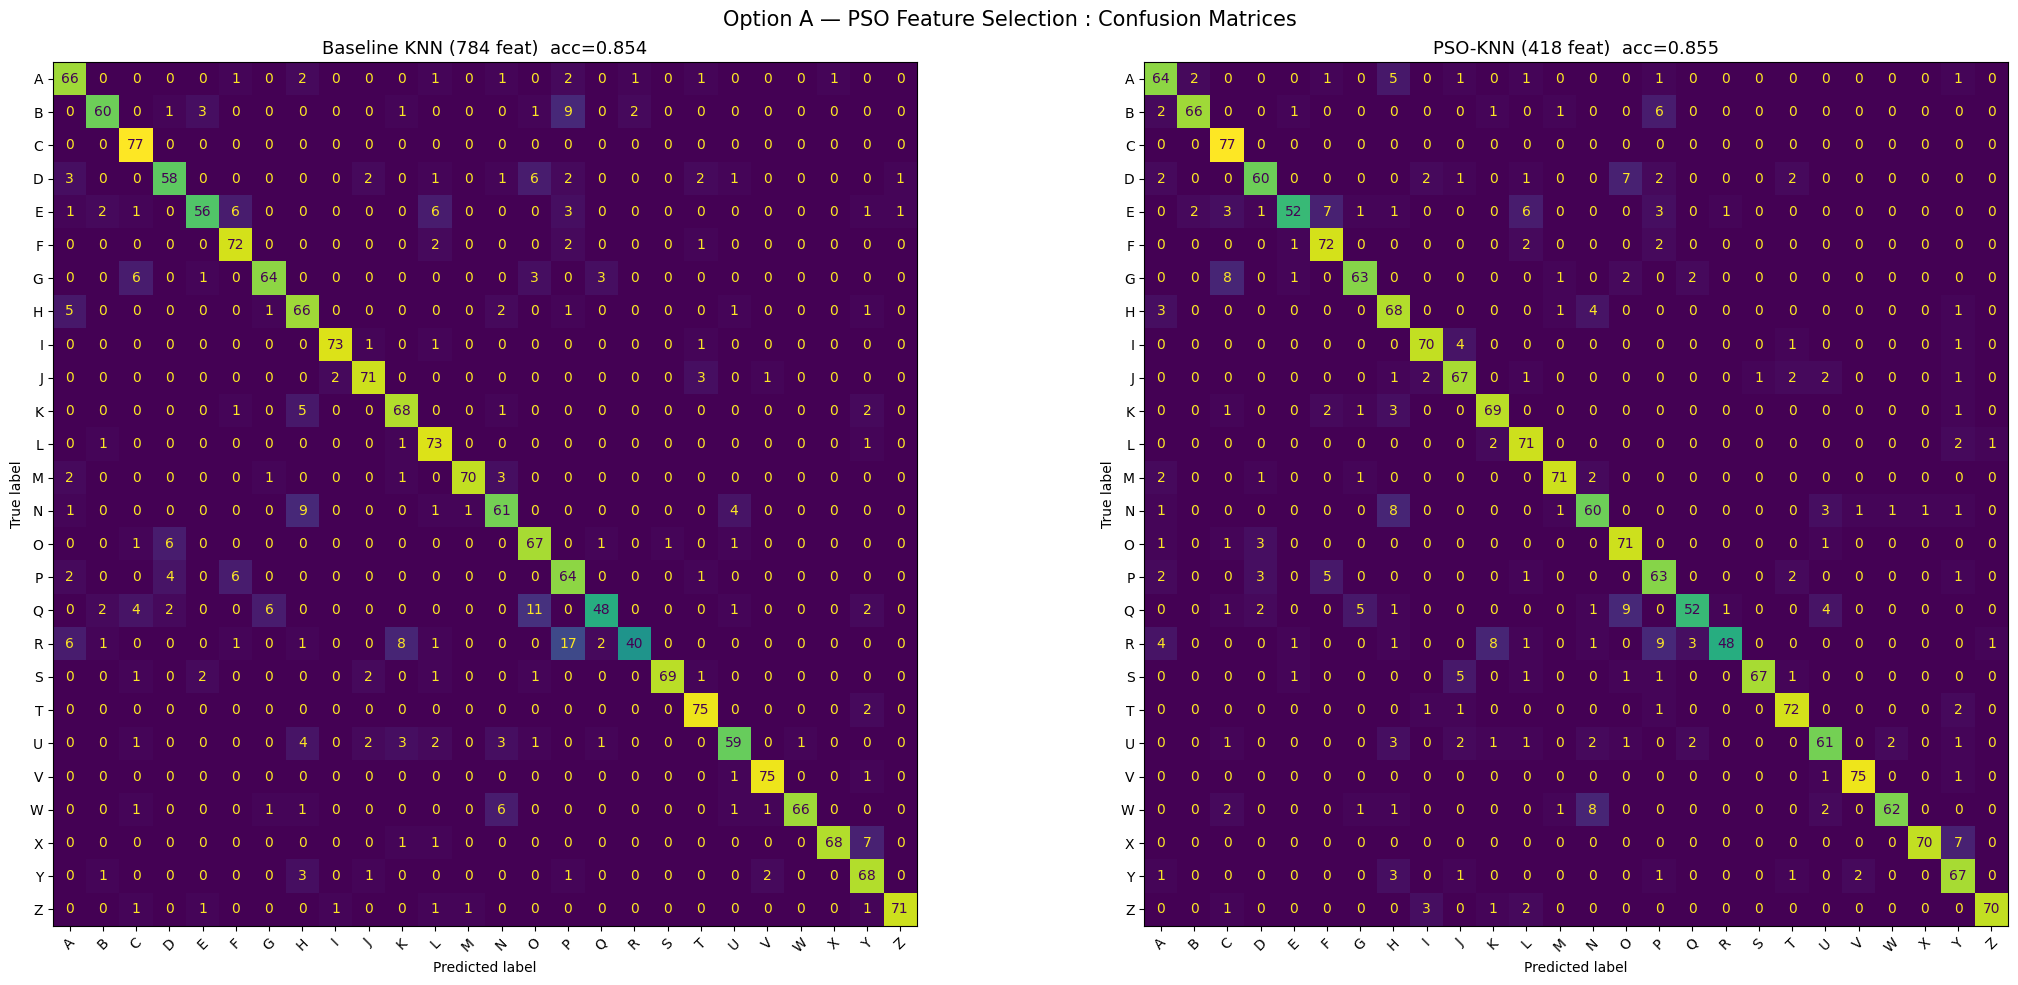

Confusion matrix saved to /content/drive/MyDrive/Models/KNN_OptionA/optionA_confusion_matrix.png


In [21]:
# ── 7. Confusion Matrix ───────────────────────────────────────
import os
save_dir = "/content/drive/MyDrive/Models/KNN_OptionA"
os.makedirs(save_dir, exist_ok=True)
fig, axes = plt.subplots(1, 2, figsize=(22, 10))
for ax, y_p, title in zip(
    axes,
    [y_pred_base, y_pred_pso],
    [f"Baseline KNN (784 feat)  acc={acc_base:.3f}",
     f"PSO-KNN ({n_selected} feat)  acc={acc_pso:.3f}"]
):
    cm = confusion_matrix(y_test, y_p)
    disp = ConfusionMatrixDisplay(cm, display_labels=[chr(65+i) for i in range(26)])
    disp.plot(ax=ax, colorbar=False, xticks_rotation=45)
    ax.set_title(title, fontsize=13)
plt.suptitle("Option A — PSO Feature Selection : Confusion Matrices", fontsize=15)
plt.tight_layout()
cm_path = os.path.join(save_dir, "optionA_confusion_matrix.png")
plt.savefig(cm_path, dpi=150)
plt.show()
print(f"Confusion matrix saved to {cm_path}")

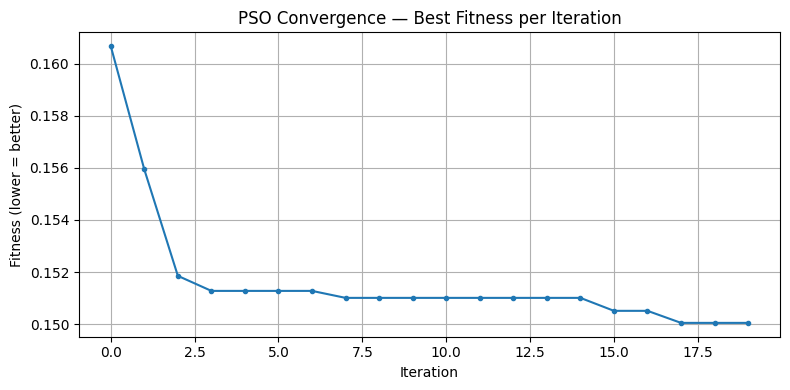

Plot saved to /content/drive/MyDrive/Models/KNN_OptionA/optionA_pso_convergence.png


In [20]:
# ── 8. PSO convergence curve ──────────────────────────────────
import os
save_dir = "/content/drive/MyDrive/Models/KNN_OptionA"
os.makedirs(save_dir, exist_ok=True)
plt.figure(figsize=(8, 4))
plt.plot(optimizer.cost_history, marker='o', markersize=3)
plt.title("PSO Convergence — Best Fitness per Iteration")
plt.xlabel("Iteration")
plt.ylabel("Fitness (lower = better)")
plt.grid()
plt.tight_layout()
plot_path = os.path.join(save_dir, "optionA_pso_convergence.png")
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"Plot saved to {plot_path}")

In [19]:
# ── 9. Results & Saving The Model ────────────────────────────────────────────────
import os
print("\n" + "="*55)
print("  OPTION A — RESULTS SUMMARY")
print("="*55)
print(f"  Baseline  acc  : {acc_base:.4f}  ({n_features} features)")
print(f"  PSO-KNN   acc  : {acc_pso:.4f}  ({n_selected} features)")
print(f"  Feature reduction : {(1 - n_selected/n_features)*100:.1f}%")
print(f"  PSO search time   : {t_pso:.1f}s")
print("="*55)
save_dir = "/content/drive/MyDrive/Models/KNN_OptionA"
# Save results for final comparison
results_A = {
    'option': 'A - PSO Feature Selection',
    'accuracy': acc_pso,
    'n_features': n_selected,
    'report': classification_report(y_test, y_pred_pso, output_dict=True,target_names=[chr(65+i) for i in range(26)])
}
save_path = os.path.join(save_dir, "results_A.npy")
np.save(save_path, results_A)
print("Results saved to results_A.npy")


  OPTION A — RESULTS SUMMARY
  Baseline  acc  : 0.8538  (784 features)
  PSO-KNN   acc  : 0.8553  (418 features)
  Feature reduction : 46.7%
  PSO search time   : 222.0s
Results saved to results_A.npy
